## Experiment 4: Performance Scaling with Increasing Data Size

### Overview
This experiment studies how DuckDB’s execution time changes as the dataset grows across different TPC-H scale factors. A fixed aggregation query is executed on increasingly larger `lineitem` tables to observe whether the engine scales smoothly with data size.

The goal is to show that DuckDB’s vectorized engine handles larger inputs by processing more fixed-size chunks through the same execution pipeline, rather than changing the execution model. Since the query includes both filtering and aggregation, this experiment reflects how DuckDB scales its filter and aggregation operators over increasing numbers of `DataChunk`s.

### Source Code Pointers
- `src/main/client_context.cpp` — query submission and execution entry
- `src/common/types/data_chunk.cpp` — chunk-based data processing
- `src/common/types/vector.cpp` — vector representation inside each chunk
- `src/execution/physical_operator.cpp` — operators executing over chunks
- `src/execution/operator/filter/physical_filter.cpp` — filtering path for the `WHERE` clause
- `src/execution/operator/aggregate/physical_hash_aggregate.cpp` — aggregation path for `GROUP BY`, `COUNT`, `SUM`, and `AVG`

Running SF = 0.01
Rows       : 60,175
Exec Time  : 0.0012s
Running SF = 0.1
Rows       : 600,572
Exec Time  : 0.0028s
Running SF = 0.5


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows       : 2,999,671
Exec Time  : 0.0108s
Running SF = 1


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows       : 6,001,215
Exec Time  : 0.0183s


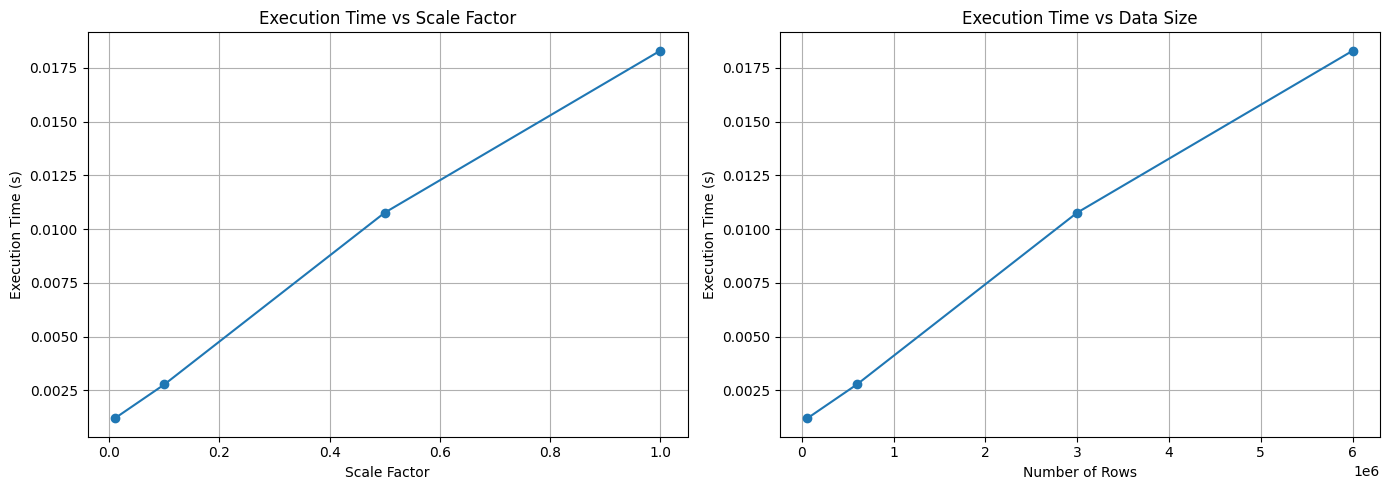

,scale_factor,row_count,execution_time
0,0.01,60175,0.001196
1,0.10,600572,0.002773
2,0.50,2999671,0.010766
3,1.00,6001215,0.018301


In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time



#  Define scale factors
SCALE_FACTORS = [0.01, 0.1, 0.5, 1]

#  Query workload
QUERY = """
SELECT 
    l_returnflag,
    COUNT(*) AS count,
    SUM(l_quantity) AS sum_qty,
    SUM(l_extendedprice) AS revenue,
    AVG(l_discount) AS avg_discount
FROM lineitem
WHERE l_shipdate <= '1998-09-01'
GROUP BY l_returnflag
"""


#  Run experiment
def run_scale_factor_experiment(scale_factors):

    results = {
        "scale_factor": [],
        "row_count": [],
        "execution_time": []
    }

    for sf in scale_factors:

        print("="*60)
        print(f"Running SF = {sf}")
        print("="*60)

        con = duckdb.connect(':memory:')
        con.execute("INSTALL tpch")
        con.execute("LOAD tpch")
        con.execute(f"CALL dbgen(sf={sf})")

        row_count = con.execute("SELECT COUNT(*) FROM lineitem").fetchone()[0]

        con.execute(QUERY).fetchall()

        start = time.perf_counter()
        con.execute(QUERY).fetchall()
        exec_time = time.perf_counter() - start

        results["scale_factor"].append(sf)
        results["row_count"].append(row_count)
        results["execution_time"].append(exec_time)

        print(f"Rows       : {row_count:,}")
        print(f"Exec Time  : {exec_time:.4f}s")

        con.close()

    return results

def plot_scale_factor_results(results):

    df = pd.DataFrame(results)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(df["scale_factor"], df["execution_time"], marker='o')
    axes[0].set_xlabel("Scale Factor")
    axes[0].set_ylabel("Execution Time (s)")
    axes[0].set_title("Execution Time vs Scale Factor")
    axes[0].grid()

    axes[1].plot(df["row_count"], df["execution_time"], marker='o')
    axes[1].set_xlabel("Number of Rows")
    axes[1].set_ylabel("Execution Time (s)")
    axes[1].set_title("Execution Time vs Data Size")
    axes[1].grid()

    plt.tight_layout()
    plt.show()

results = run_scale_factor_experiment(SCALE_FACTORS)

plot_scale_factor_results(results)

pd.DataFrame(results)